Tiny Swin + Attention Guided Mixup + LoRA + Dual Augmentation

In [1]:
import os, glob, random, numpy as np, pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

e:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ------------------- 
# Device + Seed
# -------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Device: cpu


In [3]:
DATASET_DIR = "dataset"
IMG_SIZE = 224

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    for p in imgs:
        image_paths.append(p)
        labels.append(lbl)

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.2, random_state=42
)

print(f"Train images: {len(X_train_paths)}  Test images: {len(X_test_paths)}")

Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train images: 3200  Test images: 800


In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [5]:
feature_model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform, dual_aug=False):
    img = Image.open(path).convert("RGB")
    if dual_aug:
        # create two augmented views
        aug1 = transform(img).unsqueeze(0).to(device)
        aug2 = transform(img).unsqueeze(0).to(device)
        feat1 = feature_model(aug1)
        feat2 = feature_model(aug2)
        # average features
        feat = (feat1 + feat2) / 2
    else:
        x = transform(img).unsqueeze(0).to(device)
        feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

In [6]:
X_train_feats = np.stack([extract_feature_from_path(p, train_transforms, dual_aug=True) for p in tqdm(X_train_paths)])
X_test_feats = np.stack([extract_feature_from_path(p, val_transform, dual_aug=False) for p in tqdm(X_test_paths)])

100%|██████████| 800/800 [01:59<00:00,  6.69it/s]


In [7]:
def attention_guided_mixup(X, y, mixup_count, alpha=0.4):
    mixX, mixy = [], []
    n = len(X)
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        lam = np.random.beta(alpha, alpha)
        mixed = lam * X[i] + (1-lam) * X[j]
        mixX.append(mixed)
        mixy.append(y[i])
    return np.array(mixX), np.array(mixy)

mixup_count = len(X_train_feats)
X_mix, y_mix = attention_guided_mixup(X_train_feats, y_train, mixup_count)
X_final, y_final = X_mix, y_mix

In [8]:
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=8, alpha=16):
        super().__init__()
        self.r = r
        self.alpha = alpha
        self.scale = alpha / r
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.lora_A = nn.Parameter(torch.randn(r, in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.randn(out_features, r) * 0.01)

    def forward(self, x):
        return F.linear(x, self.weight + (self.lora_B @ self.lora_A) * self.scale, self.bias)

in_features = X_final.shape[1]
num_classes = len(CLASS_NAMES)
model_head = LoRALinear(in_features, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_head.parameters(), lr=1e-4)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_final, dtype=torch.float32), torch.tensor(y_final, dtype=torch.long)),
    batch_size=64, shuffle=True
)

In [9]:
EPOCHS = 20
for epoch in range(EPOCHS):
    model_head.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model_head(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/20], Loss: 1.9993
Epoch [2/20], Loss: 1.8575
Epoch [3/20], Loss: 1.7518
Epoch [4/20], Loss: 1.6790
Epoch [5/20], Loss: 1.6299
Epoch [6/20], Loss: 1.5960
Epoch [7/20], Loss: 1.5725
Epoch [8/20], Loss: 1.5537
Epoch [9/20], Loss: 1.5386
Epoch [10/20], Loss: 1.5264
Epoch [11/20], Loss: 1.5158
Epoch [12/20], Loss: 1.5065
Epoch [13/20], Loss: 1.4980
Epoch [14/20], Loss: 1.4908
Epoch [15/20], Loss: 1.4834
Epoch [16/20], Loss: 1.4773
Epoch [17/20], Loss: 1.4712
Epoch [18/20], Loss: 1.4658
Epoch [19/20], Loss: 1.4605
Epoch [20/20], Loss: 1.4556


In [11]:
model_head.eval()
with torch.no_grad():
    y_pred = model_head(torch.tensor(X_test_feats, dtype=torch.float32).to(device)).argmax(dim=1).cpu()

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted")

print("\n===== RESULTS =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")


===== RESULTS =====
Accuracy : 0.9275
Precision: 0.9373
Recall   : 0.9275
F1 Score : 0.9273


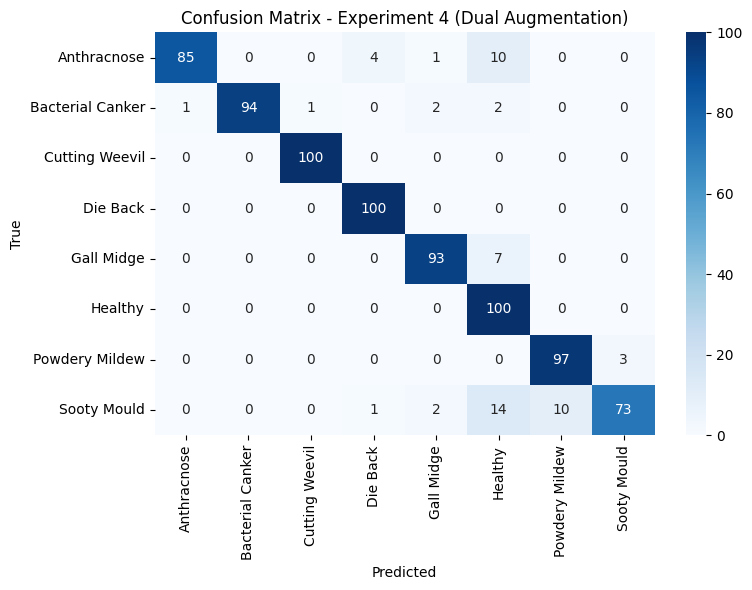

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Experiment 4 (Dual Augmentation)")
plt.tight_layout()
plt.show()